In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

In [84]:
df = pd.read_csv("crime_rate_safety_analysis.csv")
df

,incident_id,year,month,day_of_week,season,time_of_day,country,area_type,population_density_per_sqkm,crime_type,...,officers_assigned,investigation_duration_days,repeat_offender,gang_related,drug_related,cctv_coverage,lighting_condition,prior_incidents_same_location,safety_index,crime_resolved
0,CRM0000001,2022,7,Wednesday,Winter,Afternoon (12pm-6pm),Germany,Remote,16,Vandalism,...,2,46,No,No,No,No Coverage,Poorly Lit,3,62.8,No
1,CRM0000002,2024,4,Sunday,Autumn,Night (10pm-2am),Pakistan,Rural,252,Fraud,...,2,115,No,Yes,No,Partial Coverage,Partially Lit,1,50.7,No
2,CRM0000003,2023,2,Tuesday,Spring,Afternoon (12pm-6pm),USA,Rural,136,Assault,...,1,56,Yes,No,No,No Coverage,Well Lit,0,61.3,Yes
3,CRM0000004,2023,5,Saturday,Autumn,Evening (6pm-10pm),India,Rural,354,Robbery,...,4,44,Yes,Yes,No,Partial Coverage,Partially Lit,6,51.7,Yes
4,CRM0000005,2021,11,Saturday,Spring,Afternoon (12pm-6pm),Mexico,Urban,817,Burglary,...,5,111,No,Unknown,Yes,Partial Coverage,Partially Lit,2,52.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,CRM0009996,2024,11,Thursday,Winter,Morning (6am-12pm),Turkey,Suburban,327,Burglary,...,3,27,No,Yes,No,Partial Coverage,Well Lit,5,75.6,No
9996,CRM0009997,2024,4,Tuesday,Spring,Afternoon (12pm-6pm),Germany,Urban,1136,Burglary,...,5,41,No,No,No,Partial Coverage,Partially Lit,0,61.4,No
9997,CRM0009998,2024,11,Tuesday,Summer,Evening (6pm-10pm),France,Suburban,436,Assault,...,3,30,Unknown,No,Yes,Partial Coverage,Poorly Lit,1,65.1,Yes
9998,CRM0009999,2022,1,Friday,Summer,Evening (6pm-10pm),USA,Rural,169,Cybercrime,...,1,27,Unknown,No,No,Partial Coverage,Well Lit,2,77.5,No


In [85]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   incident_id                    10000 non-null  str    
 1   year                           10000 non-null  int64  
 2   month                          10000 non-null  int64  
 3   day_of_week                    10000 non-null  str    
 4   season                         10000 non-null  str    
 5   time_of_day                    10000 non-null  str    
 6   country                        10000 non-null  str    
 7   area_type                      10000 non-null  str    
 8   population_density_per_sqkm    10000 non-null  int64  
 9   crime_type                     10000 non-null  str    
 10  crime_severity_score           10000 non-null  float64
 11  victim_count                   10000 non-null  int64  
 12  victim_gender                  10000 non-null  str    
 13

In [86]:
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   incident_id                    10000 non-null  str    
 1   year                           10000 non-null  int64  
 2   month                          10000 non-null  int64  
 3   day_of_week                    10000 non-null  str    
 4   season                         10000 non-null  str    
 5   time_of_day                    10000 non-null  str    
 6   country                        10000 non-null  str    
 7   area_type                      10000 non-null  str    
 8   population_density_per_sqkm    10000 non-null  int64  
 9   crime_type                     10000 non-null  str    
 10  crime_severity_score           10000 non-null  float64
 11  victim_count                   10000 non-null  int64  
 12  victim_gender                  10000 non-null  str    
 13

In [87]:
df.memory_usage(deep=True)

Index                               132
incident_id                      180000
year                              80000
month                             80000
day_of_week                      151536
season                           140000
time_of_day                      261172
country                          142601
area_type                        139734
population_density_per_sqkm       80000
crime_type                       163263
crime_severity_score              80000
victim_count                      80000
victim_gender                    130131
victim_age_group                 130632
injuries_reported                 80000
fatalities                        80000
financial_loss_usd                80000
weapon_used                      127659
suspect_status                   180662
case_status                      228574
reporting_method                 219984
response_time_minutes             80000
officers_assigned                 80000
investigation_duration_days       80000


In [88]:
df.columns

Index(['incident_id', 'year', 'month', 'day_of_week', 'season', 'time_of_day',
       'country', 'area_type', 'population_density_per_sqkm', 'crime_type',
       'crime_severity_score', 'victim_count', 'victim_gender',
       'victim_age_group', 'injuries_reported', 'fatalities',
       'financial_loss_usd', 'weapon_used', 'suspect_status', 'case_status',
       'reporting_method', 'response_time_minutes', 'officers_assigned',
       'investigation_duration_days', 'repeat_offender', 'gang_related',
       'drug_related', 'cctv_coverage', 'lighting_condition',
       'prior_incidents_same_location', 'safety_index', 'crime_resolved'],
      dtype='str')

In [89]:
df = df.drop(columns=['incident_id'])
df

,year,month,day_of_week,season,time_of_day,country,area_type,population_density_per_sqkm,crime_type,crime_severity_score,...,officers_assigned,investigation_duration_days,repeat_offender,gang_related,drug_related,cctv_coverage,lighting_condition,prior_incidents_same_location,safety_index,crime_resolved
0,2022,7,Wednesday,Winter,Afternoon (12pm-6pm),Germany,Remote,16,Vandalism,2.7,...,2,46,No,No,No,No Coverage,Poorly Lit,3,62.8,No
1,2024,4,Sunday,Autumn,Night (10pm-2am),Pakistan,Rural,252,Fraud,3.5,...,2,115,No,Yes,No,Partial Coverage,Partially Lit,1,50.7,No
2,2023,2,Tuesday,Spring,Afternoon (12pm-6pm),USA,Rural,136,Assault,5.7,...,1,56,Yes,No,No,No Coverage,Well Lit,0,61.3,Yes
3,2023,5,Saturday,Autumn,Evening (6pm-10pm),India,Rural,354,Robbery,7.0,...,4,44,Yes,Yes,No,Partial Coverage,Partially Lit,6,51.7,Yes
4,2021,11,Saturday,Spring,Afternoon (12pm-6pm),Mexico,Urban,817,Burglary,4.6,...,5,111,No,Unknown,Yes,Partial Coverage,Partially Lit,2,52.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2024,11,Thursday,Winter,Morning (6am-12pm),Turkey,Suburban,327,Burglary,5.2,...,3,27,No,Yes,No,Partial Coverage,Well Lit,5,75.6,No
9996,2024,4,Tuesday,Spring,Afternoon (12pm-6pm),Germany,Urban,1136,Burglary,7.0,...,5,41,No,No,No,Partial Coverage,Partially Lit,0,61.4,No
9997,2024,11,Tuesday,Summer,Evening (6pm-10pm),France,Suburban,436,Assault,5.2,...,3,30,Unknown,No,Yes,Partial Coverage,Poorly Lit,1,65.1,Yes
9998,2022,1,Friday,Summer,Evening (6pm-10pm),USA,Rural,169,Cybercrime,5.4,...,1,27,Unknown,No,No,Partial Coverage,Well Lit,2,77.5,No


-int 
-categoria
-str -> muito espaço
-float -> muito espaço
-booleano -> pouco espaço 

In [90]:
df['lighting_condition'].unique()

<ArrowStringArray>
['Poorly Lit', 'Partially Lit', 'Well Lit', 'No Lighting']
Length: 4, dtype: str

In [91]:
df['lighting_condition'] = df['lighting_condition'].map({
    'No Lighting':0,
    'Poorly Lit':1,
    'Partially Lit':2,
    'Well Lit':3
}).astype('category')

In [92]:
df['crime_resolved'].unique()

<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

In [93]:
df['crime_resolved'] = df['crime_resolved'].map({'No': 0, 'Yes': 1}).astype(bool)
df

,year,month,day_of_week,season,time_of_day,country,area_type,population_density_per_sqkm,crime_type,crime_severity_score,...,officers_assigned,investigation_duration_days,repeat_offender,gang_related,drug_related,cctv_coverage,lighting_condition,prior_incidents_same_location,safety_index,crime_resolved
0,2022,7,Wednesday,Winter,Afternoon (12pm-6pm),Germany,Remote,16,Vandalism,2.7,...,2,46,No,No,No,No Coverage,1,3,62.8,False
1,2024,4,Sunday,Autumn,Night (10pm-2am),Pakistan,Rural,252,Fraud,3.5,...,2,115,No,Yes,No,Partial Coverage,2,1,50.7,False
2,2023,2,Tuesday,Spring,Afternoon (12pm-6pm),USA,Rural,136,Assault,5.7,...,1,56,Yes,No,No,No Coverage,3,0,61.3,True
3,2023,5,Saturday,Autumn,Evening (6pm-10pm),India,Rural,354,Robbery,7.0,...,4,44,Yes,Yes,No,Partial Coverage,2,6,51.7,True
4,2021,11,Saturday,Spring,Afternoon (12pm-6pm),Mexico,Urban,817,Burglary,4.6,...,5,111,No,Unknown,Yes,Partial Coverage,2,2,52.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2024,11,Thursday,Winter,Morning (6am-12pm),Turkey,Suburban,327,Burglary,5.2,...,3,27,No,Yes,No,Partial Coverage,3,5,75.6,False
9996,2024,4,Tuesday,Spring,Afternoon (12pm-6pm),Germany,Urban,1136,Burglary,7.0,...,5,41,No,No,No,Partial Coverage,2,0,61.4,False
9997,2024,11,Tuesday,Summer,Evening (6pm-10pm),France,Suburban,436,Assault,5.2,...,3,30,Unknown,No,Yes,Partial Coverage,1,1,65.1,True
9998,2022,1,Friday,Summer,Evening (6pm-10pm),USA,Rural,169,Cybercrime,5.4,...,1,27,Unknown,No,No,Partial Coverage,3,2,77.5,False


In [94]:
df['season'].unique()

<ArrowStringArray>
['Winter', 'Autumn', 'Spring', 'Summer']
Length: 4, dtype: str

In [95]:
df['season'] = df['season'].map({'Winter': 0, 'Autumn': 1, 'Spring': 2, 'Summer': 3}).astype('category')
df

,year,month,day_of_week,season,time_of_day,country,area_type,population_density_per_sqkm,crime_type,crime_severity_score,...,officers_assigned,investigation_duration_days,repeat_offender,gang_related,drug_related,cctv_coverage,lighting_condition,prior_incidents_same_location,safety_index,crime_resolved
0,2022,7,Wednesday,0,Afternoon (12pm-6pm),Germany,Remote,16,Vandalism,2.7,...,2,46,No,No,No,No Coverage,1,3,62.8,False
1,2024,4,Sunday,1,Night (10pm-2am),Pakistan,Rural,252,Fraud,3.5,...,2,115,No,Yes,No,Partial Coverage,2,1,50.7,False
2,2023,2,Tuesday,2,Afternoon (12pm-6pm),USA,Rural,136,Assault,5.7,...,1,56,Yes,No,No,No Coverage,3,0,61.3,True
3,2023,5,Saturday,1,Evening (6pm-10pm),India,Rural,354,Robbery,7.0,...,4,44,Yes,Yes,No,Partial Coverage,2,6,51.7,True
4,2021,11,Saturday,2,Afternoon (12pm-6pm),Mexico,Urban,817,Burglary,4.6,...,5,111,No,Unknown,Yes,Partial Coverage,2,2,52.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2024,11,Thursday,0,Morning (6am-12pm),Turkey,Suburban,327,Burglary,5.2,...,3,27,No,Yes,No,Partial Coverage,3,5,75.6,False
9996,2024,4,Tuesday,2,Afternoon (12pm-6pm),Germany,Urban,1136,Burglary,7.0,...,5,41,No,No,No,Partial Coverage,2,0,61.4,False
9997,2024,11,Tuesday,3,Evening (6pm-10pm),France,Suburban,436,Assault,5.2,...,3,30,Unknown,No,Yes,Partial Coverage,1,1,65.1,True
9998,2022,1,Friday,3,Evening (6pm-10pm),USA,Rural,169,Cybercrime,5.4,...,1,27,Unknown,No,No,Partial Coverage,3,2,77.5,False


In [96]:
df['area_type'].unique()

<ArrowStringArray>
['Remote', 'Rural', 'Urban', 'Suburban']
Length: 4, dtype: str

In [97]:
df['area_type'] = df['area_type'].map({'Remote': 0,'Rural': 1,'Urban':2,'Suburban':3}).astype('category')
df 

,year,month,day_of_week,season,time_of_day,country,area_type,population_density_per_sqkm,crime_type,crime_severity_score,...,officers_assigned,investigation_duration_days,repeat_offender,gang_related,drug_related,cctv_coverage,lighting_condition,prior_incidents_same_location,safety_index,crime_resolved
0,2022,7,Wednesday,0,Afternoon (12pm-6pm),Germany,0,16,Vandalism,2.7,...,2,46,No,No,No,No Coverage,1,3,62.8,False
1,2024,4,Sunday,1,Night (10pm-2am),Pakistan,1,252,Fraud,3.5,...,2,115,No,Yes,No,Partial Coverage,2,1,50.7,False
2,2023,2,Tuesday,2,Afternoon (12pm-6pm),USA,1,136,Assault,5.7,...,1,56,Yes,No,No,No Coverage,3,0,61.3,True
3,2023,5,Saturday,1,Evening (6pm-10pm),India,1,354,Robbery,7.0,...,4,44,Yes,Yes,No,Partial Coverage,2,6,51.7,True
4,2021,11,Saturday,2,Afternoon (12pm-6pm),Mexico,2,817,Burglary,4.6,...,5,111,No,Unknown,Yes,Partial Coverage,2,2,52.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2024,11,Thursday,0,Morning (6am-12pm),Turkey,3,327,Burglary,5.2,...,3,27,No,Yes,No,Partial Coverage,3,5,75.6,False
9996,2024,4,Tuesday,2,Afternoon (12pm-6pm),Germany,2,1136,Burglary,7.0,...,5,41,No,No,No,Partial Coverage,2,0,61.4,False
9997,2024,11,Tuesday,3,Evening (6pm-10pm),France,3,436,Assault,5.2,...,3,30,Unknown,No,Yes,Partial Coverage,1,1,65.1,True
9998,2022,1,Friday,3,Evening (6pm-10pm),USA,1,169,Cybercrime,5.4,...,1,27,Unknown,No,No,Partial Coverage,3,2,77.5,False


In [98]:
df['victim_gender'].value_counts()

victim_gender
Male       5226
Female     4191
Unknown     583
Name: count, dtype: int64

In [99]:
df['victim_gender'].unique()

<ArrowStringArray>
['Female', 'Male', 'Unknown']
Length: 3, dtype: str

In [100]:
df['victim_gender'] = df['victim_gender'].map({'Female': 0,'Male': 1,'Unknown':2}).astype('category')
df 

,year,month,day_of_week,season,time_of_day,country,area_type,population_density_per_sqkm,crime_type,crime_severity_score,...,officers_assigned,investigation_duration_days,repeat_offender,gang_related,drug_related,cctv_coverage,lighting_condition,prior_incidents_same_location,safety_index,crime_resolved
0,2022,7,Wednesday,0,Afternoon (12pm-6pm),Germany,0,16,Vandalism,2.7,...,2,46,No,No,No,No Coverage,1,3,62.8,False
1,2024,4,Sunday,1,Night (10pm-2am),Pakistan,1,252,Fraud,3.5,...,2,115,No,Yes,No,Partial Coverage,2,1,50.7,False
2,2023,2,Tuesday,2,Afternoon (12pm-6pm),USA,1,136,Assault,5.7,...,1,56,Yes,No,No,No Coverage,3,0,61.3,True
3,2023,5,Saturday,1,Evening (6pm-10pm),India,1,354,Robbery,7.0,...,4,44,Yes,Yes,No,Partial Coverage,2,6,51.7,True
4,2021,11,Saturday,2,Afternoon (12pm-6pm),Mexico,2,817,Burglary,4.6,...,5,111,No,Unknown,Yes,Partial Coverage,2,2,52.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2024,11,Thursday,0,Morning (6am-12pm),Turkey,3,327,Burglary,5.2,...,3,27,No,Yes,No,Partial Coverage,3,5,75.6,False
9996,2024,4,Tuesday,2,Afternoon (12pm-6pm),Germany,2,1136,Burglary,7.0,...,5,41,No,No,No,Partial Coverage,2,0,61.4,False
9997,2024,11,Tuesday,3,Evening (6pm-10pm),France,3,436,Assault,5.2,...,3,30,Unknown,No,Yes,Partial Coverage,1,1,65.1,True
9998,2022,1,Friday,3,Evening (6pm-10pm),USA,1,169,Cybercrime,5.4,...,1,27,Unknown,No,No,Partial Coverage,3,2,77.5,False


In [101]:
df['month'] = df['month'].astype('int8')

In [102]:
df['country'].nunique()

15

In [103]:
df['day_of_week'].unique()

<ArrowStringArray>
['Wednesday', 'Sunday', 'Tuesday', 'Saturday', 'Monday', 'Thursday', 'Friday']
Length: 7, dtype: str

In [104]:
df['day_of_week'] = df['day_of_week'].map({'Sunday': 0,'Monday': 1,'Tuesday':2,'Wednesday':3, 'Thursday':4, 'Friday':5 , 'Saturday':6}).astype('category')
df 

,year,month,day_of_week,season,time_of_day,country,area_type,population_density_per_sqkm,crime_type,crime_severity_score,...,officers_assigned,investigation_duration_days,repeat_offender,gang_related,drug_related,cctv_coverage,lighting_condition,prior_incidents_same_location,safety_index,crime_resolved
0,2022,7,3,0,Afternoon (12pm-6pm),Germany,0,16,Vandalism,2.7,...,2,46,No,No,No,No Coverage,1,3,62.8,False
1,2024,4,0,1,Night (10pm-2am),Pakistan,1,252,Fraud,3.5,...,2,115,No,Yes,No,Partial Coverage,2,1,50.7,False
2,2023,2,2,2,Afternoon (12pm-6pm),USA,1,136,Assault,5.7,...,1,56,Yes,No,No,No Coverage,3,0,61.3,True
3,2023,5,6,1,Evening (6pm-10pm),India,1,354,Robbery,7.0,...,4,44,Yes,Yes,No,Partial Coverage,2,6,51.7,True
4,2021,11,6,2,Afternoon (12pm-6pm),Mexico,2,817,Burglary,4.6,...,5,111,No,Unknown,Yes,Partial Coverage,2,2,52.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2024,11,4,0,Morning (6am-12pm),Turkey,3,327,Burglary,5.2,...,3,27,No,Yes,No,Partial Coverage,3,5,75.6,False
9996,2024,4,2,2,Afternoon (12pm-6pm),Germany,2,1136,Burglary,7.0,...,5,41,No,No,No,Partial Coverage,2,0,61.4,False
9997,2024,11,2,3,Evening (6pm-10pm),France,3,436,Assault,5.2,...,3,30,Unknown,No,Yes,Partial Coverage,1,1,65.1,True
9998,2022,1,5,3,Evening (6pm-10pm),USA,1,169,Cybercrime,5.4,...,1,27,Unknown,No,No,Partial Coverage,3,2,77.5,False


In [105]:
df['victim_age_group'].unique()

<ArrowStringArray>
['65+', '26-35', '18-25', '36-45', '46-55', '56-65', 'Under 18']
Length: 7, dtype: str

In [106]:
df['victim_age_group'] = df['victim_age_group'].map({'65+': 6, '26-35': 2, '18-25': 1, '36-45': 3, '46-55': 4, '56-65': 5, 'Under 18': 0}).astype('category')
df

,year,month,day_of_week,season,time_of_day,country,area_type,population_density_per_sqkm,crime_type,crime_severity_score,...,officers_assigned,investigation_duration_days,repeat_offender,gang_related,drug_related,cctv_coverage,lighting_condition,prior_incidents_same_location,safety_index,crime_resolved
0,2022,7,3,0,Afternoon (12pm-6pm),Germany,0,16,Vandalism,2.7,...,2,46,No,No,No,No Coverage,1,3,62.8,False
1,2024,4,0,1,Night (10pm-2am),Pakistan,1,252,Fraud,3.5,...,2,115,No,Yes,No,Partial Coverage,2,1,50.7,False
2,2023,2,2,2,Afternoon (12pm-6pm),USA,1,136,Assault,5.7,...,1,56,Yes,No,No,No Coverage,3,0,61.3,True
3,2023,5,6,1,Evening (6pm-10pm),India,1,354,Robbery,7.0,...,4,44,Yes,Yes,No,Partial Coverage,2,6,51.7,True
4,2021,11,6,2,Afternoon (12pm-6pm),Mexico,2,817,Burglary,4.6,...,5,111,No,Unknown,Yes,Partial Coverage,2,2,52.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2024,11,4,0,Morning (6am-12pm),Turkey,3,327,Burglary,5.2,...,3,27,No,Yes,No,Partial Coverage,3,5,75.6,False
9996,2024,4,2,2,Afternoon (12pm-6pm),Germany,2,1136,Burglary,7.0,...,5,41,No,No,No,Partial Coverage,2,0,61.4,False
9997,2024,11,2,3,Evening (6pm-10pm),France,3,436,Assault,5.2,...,3,30,Unknown,No,Yes,Partial Coverage,1,1,65.1,True
9998,2022,1,5,3,Evening (6pm-10pm),USA,1,169,Cybercrime,5.4,...,1,27,Unknown,No,No,Partial Coverage,3,2,77.5,False


In [107]:
df['time_of_day'].unique()

<ArrowStringArray>
['Afternoon (12pm-6pm)',     'Night (10pm-2am)',   'Evening (6pm-10pm)',
   'Morning (6am-12pm)', 'Late Night (2am-6am)']
Length: 5, dtype: str

In [108]:
df['time_of_day'] = df['time_of_day'].map({'Afternoon (12pm-6pm)':1,'Night (10pm-2am)':3,'Evening (6pm-10pm)':2, 'Morning (6am-12pm)': 0,'Late Night (2am-6am)':4}).astype('category')
df

,year,month,day_of_week,season,time_of_day,country,area_type,population_density_per_sqkm,crime_type,crime_severity_score,...,officers_assigned,investigation_duration_days,repeat_offender,gang_related,drug_related,cctv_coverage,lighting_condition,prior_incidents_same_location,safety_index,crime_resolved
0,2022,7,3,0,1,Germany,0,16,Vandalism,2.7,...,2,46,No,No,No,No Coverage,1,3,62.8,False
1,2024,4,0,1,3,Pakistan,1,252,Fraud,3.5,...,2,115,No,Yes,No,Partial Coverage,2,1,50.7,False
2,2023,2,2,2,1,USA,1,136,Assault,5.7,...,1,56,Yes,No,No,No Coverage,3,0,61.3,True
3,2023,5,6,1,2,India,1,354,Robbery,7.0,...,4,44,Yes,Yes,No,Partial Coverage,2,6,51.7,True
4,2021,11,6,2,1,Mexico,2,817,Burglary,4.6,...,5,111,No,Unknown,Yes,Partial Coverage,2,2,52.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2024,11,4,0,0,Turkey,3,327,Burglary,5.2,...,3,27,No,Yes,No,Partial Coverage,3,5,75.6,False
9996,2024,4,2,2,1,Germany,2,1136,Burglary,7.0,...,5,41,No,No,No,Partial Coverage,2,0,61.4,False
9997,2024,11,2,3,2,France,3,436,Assault,5.2,...,3,30,Unknown,No,Yes,Partial Coverage,1,1,65.1,True
9998,2022,1,5,3,2,USA,1,169,Cybercrime,5.4,...,1,27,Unknown,No,No,Partial Coverage,3,2,77.5,False


In [109]:
df['population_density_per_sqkm'].max()

np.int64(30210)

In [110]:
df['crime_type'].unique()

<ArrowStringArray>
[        'Vandalism',             'Fraud',           'Assault',
           'Robbery',          'Burglary',             'Theft',
        'Cybercrime',            'Murder',    'Sexual Assault',
        'Kidnapping', 'Domestic Violence',      'Drug Offense',
             'Arson',         'Extortion',       'Trafficking']
Length: 15, dtype: str

In [111]:
df['crime_type'] = df['crime_type'].map({'Vandalism':0,'Fraud':1,'Assault':2,'Robbery':3,'Burglary':4,'Theft':5,
'Cybercrime':6,'Murder':7,'Sexual Assault':8, 'Kidnapping':9, 'Domestic Violence':10, 'Drug Offense':11,
'Arson':12, 'Extortion':13,'Trafficking':14}).astype('category')
df

,year,month,day_of_week,season,time_of_day,country,area_type,population_density_per_sqkm,crime_type,crime_severity_score,...,officers_assigned,investigation_duration_days,repeat_offender,gang_related,drug_related,cctv_coverage,lighting_condition,prior_incidents_same_location,safety_index,crime_resolved
0,2022,7,3,0,1,Germany,0,16,0,2.7,...,2,46,No,No,No,No Coverage,1,3,62.8,False
1,2024,4,0,1,3,Pakistan,1,252,1,3.5,...,2,115,No,Yes,No,Partial Coverage,2,1,50.7,False
2,2023,2,2,2,1,USA,1,136,2,5.7,...,1,56,Yes,No,No,No Coverage,3,0,61.3,True
3,2023,5,6,1,2,India,1,354,3,7.0,...,4,44,Yes,Yes,No,Partial Coverage,2,6,51.7,True
4,2021,11,6,2,1,Mexico,2,817,4,4.6,...,5,111,No,Unknown,Yes,Partial Coverage,2,2,52.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2024,11,4,0,0,Turkey,3,327,4,5.2,...,3,27,No,Yes,No,Partial Coverage,3,5,75.6,False
9996,2024,4,2,2,1,Germany,2,1136,4,7.0,...,5,41,No,No,No,Partial Coverage,2,0,61.4,False
9997,2024,11,2,3,2,France,3,436,2,5.2,...,3,30,Unknown,No,Yes,Partial Coverage,1,1,65.1,True
9998,2022,1,5,3,2,USA,1,169,6,5.4,...,1,27,Unknown,No,No,Partial Coverage,3,2,77.5,False


In [112]:
df['gang_related'].unique()

<ArrowStringArray>
['No', 'Yes', 'Unknown']
Length: 3, dtype: str

In [113]:
df['drug_related'].unique()

<ArrowStringArray>
['No', 'Yes', 'Unknown']
Length: 3, dtype: str

In [114]:
df['gang_related'] = df['gang_related'].map({'No': 0, 'Yes':1, 'Unknown':2}).astype('category')

In [115]:
df['drug_related'] = df['drug_related'].map({'No': 0, 'Yes':1, 'Unknown':2}).astype('category')

In [116]:
#for col in['drug_related', 'gang_related']: df[col] = df[col].astype('category')

In [117]:
categoricas = [
    'country',
    'weapon_used',
    'suspect_status',
    'case_status',
    'reporting_method',
    'repeat_offender',
    'cctv_coverage',
    'lighting_condition'
]

for col in categoricas:
    df[col] = df[col].astype('category')

In [118]:
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   year                           10000 non-null  int64   
 1   month                          10000 non-null  int8    
 2   day_of_week                    10000 non-null  category
 3   season                         10000 non-null  category
 4   time_of_day                    10000 non-null  category
 5   country                        10000 non-null  category
 6   area_type                      10000 non-null  category
 7   population_density_per_sqkm    10000 non-null  int64   
 8   crime_type                     10000 non-null  category
 9   crime_severity_score           10000 non-null  float64 
 10  victim_count                   10000 non-null  int64   
 11  victim_gender                  10000 non-null  category
 12  victim_age_group               10000 non-nul

In [119]:
print(df.dtypes.value_counts())

int64       8
float64     4
category    3
category    3
category    2
int8        1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
bool        1
Name: count, dtype: int64


In [120]:
df_original = pd.read_csv('crime_rate_safety_analysis.csv')

print(f'Uso de memória ANTES da otimização(Real): {df_original.memory_usage(deep=True).sum() / 1024:.2f} KB')
print(f'Uso de memória DEPOIS da otimização(Padrão): {df.memory_usage(deep=False).sum() / 1024:.2f} KB')

Uso de memória ANTES da otimização(Real): 3971.29 KB
Uso de memória DEPOIS da otimização(Padrão): 1124.51 KB


In [121]:
#df.to_parquet('crime_rate_safety_analysis_optimized.parquet', index=False)

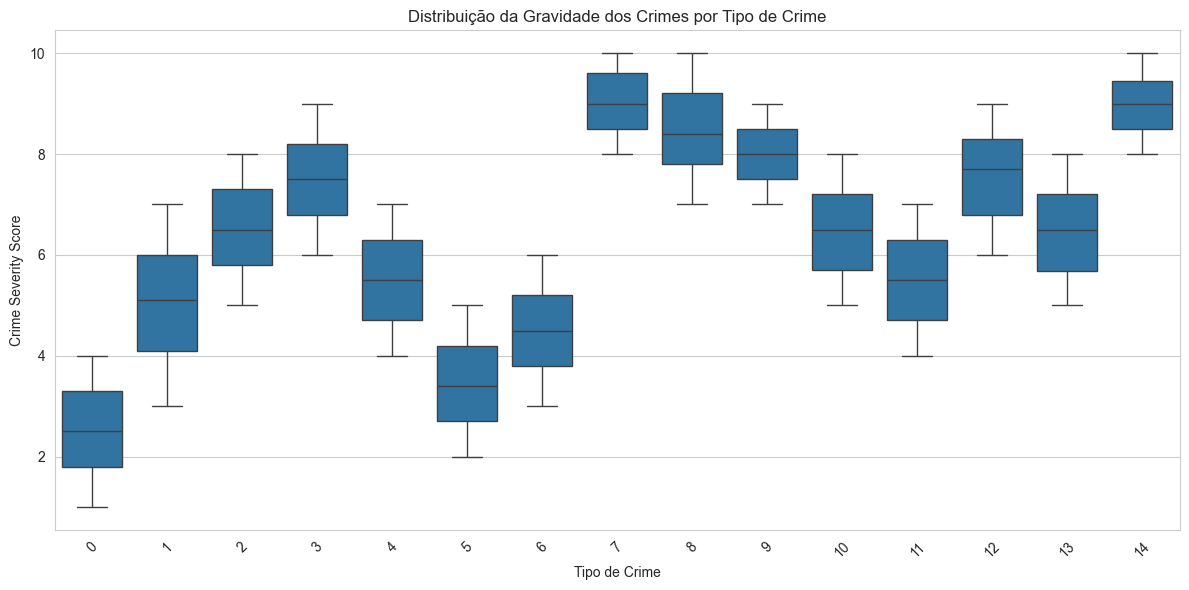

In [125]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='crime_type',
    y='crime_severity_score'
)

plt.title('Distribuição da Gravidade dos Crimes por Tipo de Crime')
plt.xlabel('Tipo de Crime')
plt.ylabel('Crime Severity Score')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

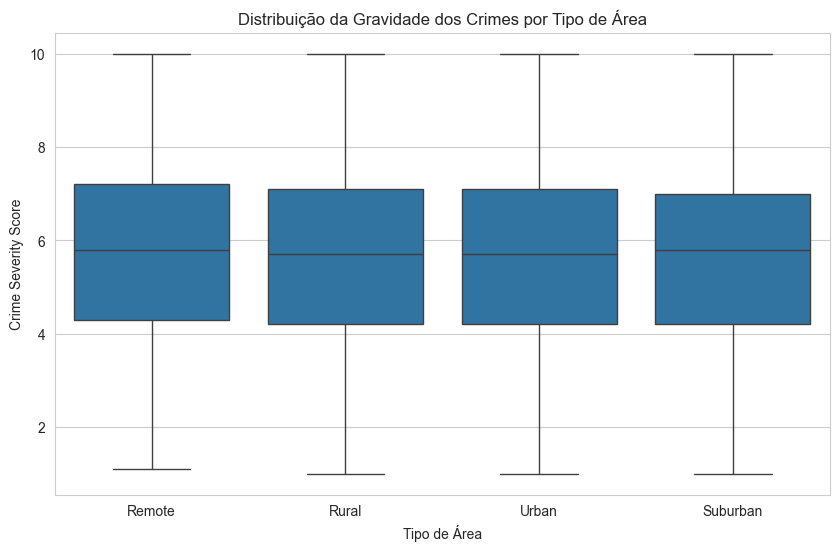

In [133]:
labels_area = {
    0:'Remote',
    1:'Rural',
    2:'Urban',
    3:'Suburban'
}

df_box = df.copy()

df_box['area_type'] = df_box['area_type'].astype(int)
df_box['area_type'] = df_box['area_type'].map(labels_area)

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_box,
    x='area_type',
    y='crime_severity_score'
)

plt.title('Distribuição da Gravidade dos Crimes por Tipo de Área')
plt.xlabel('Tipo de Área')
plt.ylabel('Crime Severity Score')

plt.show()

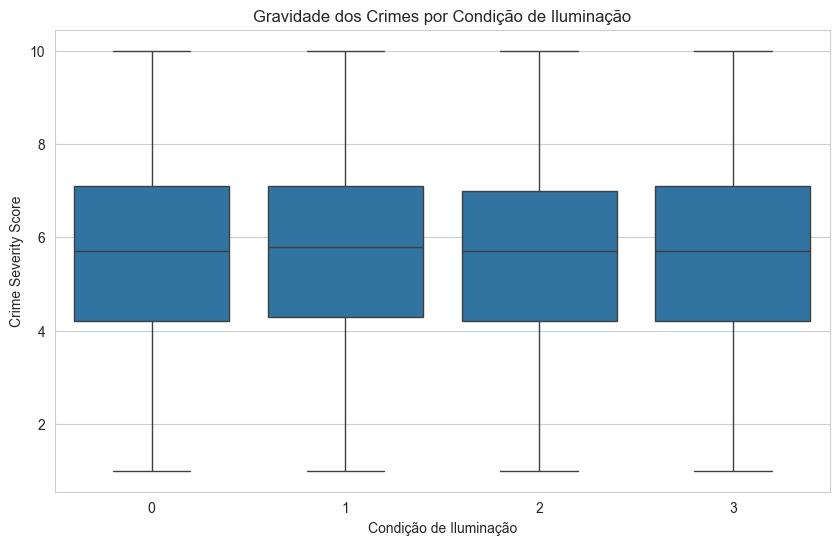

In [126]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='lighting_condition',
    y='crime_severity_score'
)

plt.title('Gravidade dos Crimes por Condição de Iluminação')
plt.xlabel('Condição de Iluminação')
plt.ylabel('Crime Severity Score')

plt.show()

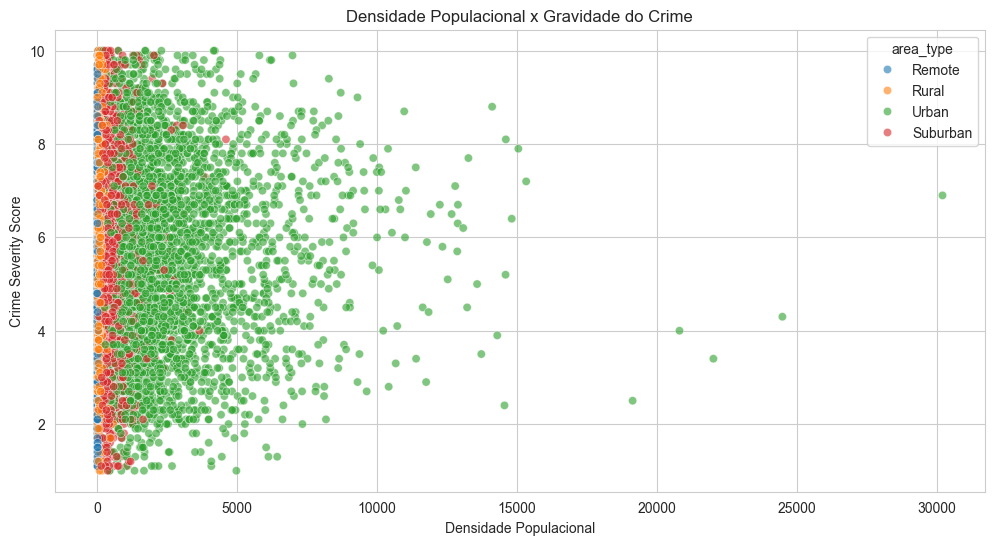

In [130]:
labels_area = {
    0:'Remote',
    1:'Rural',
    2:'Urban',
    3:'Suburban'
}

df_plot = df.copy()

df_plot['area_type'] = df_plot['area_type'].astype(int)
df_plot['area_type'] = df_plot['area_type'].map(labels_area)

plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df_plot,
    x='population_density_per_sqkm',
    y='crime_severity_score',
    hue='area_type',
    alpha=0.6
)

plt.title('Densidade Populacional x Gravidade do Crime')
plt.xlabel('Densidade Populacional')
plt.ylabel('Crime Severity Score')

plt.show()

Text(0, 0.5, 'Frequência')

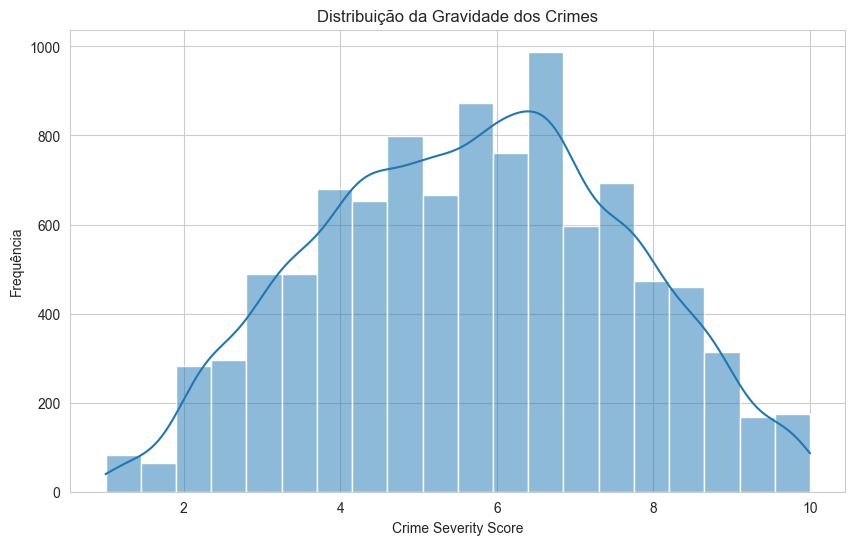

In [134]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='crime_severity_score',
    bins=20,
    kde=True
)

plt.title('Distribuição da Gravidade dos Crimes')
plt.xlabel('Crime Severity Score')
plt.ylabel('Frequência')
